In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/2.-Gold/ml_dataset.csv")

print(df.shape)

df.head()

(1098, 39)


,fecha,id_sku,categoria,volumen_litros,formato_envase,cantidad_vendida_total,stock_apertura,ingresos_almacen,stock_disponible_cierre,stock_minimo,...,temporada,ventas_lag1,ventas_lag7,ventas_roll7,ads_lag1,ads_lag3,riesgo_demanda_censurada,fecha_creacion,fecha_modificacion,usuario_modificacion
0,2024-01-01,SKU_1L,Personal,1.0,Botella,153,540,0,411,180,...,Verano,0,0,153.00,0.00,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
1,2024-01-02,SKU_1L,Personal,1.0,Botella,51,411,0,339,180,...,Verano,153,0,102.00,0.00,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
2,2024-01-03,SKU_1L,Personal,1.0,Botella,132,339,0,207,180,...,Verano,51,0,112.00,0.00,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
3,2024-01-04,SKU_1L,Personal,1.0,Botella,147,568,361,421,180,...,Verano,132,0,120.75,79.02,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres
4,2024-01-05,SKU_1L,Personal,1.0,Botella,132,421,0,289,180,...,Verano,147,0,123.00,69.98,0.0,False,2026-05-31 02:43:34.222205,2026-05-31 02:43:34.222205,postgres


In [2]:
df.shape

(1098, 39)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fecha                          1098 non-null   str    
 1   id_sku                         1098 non-null   str    
 2   categoria                      1098 non-null   str    
 3   volumen_litros                 1098 non-null   float64
 4   formato_envase                 1098 non-null   str    
 5   cantidad_vendida_total         1098 non-null   int64  
 6   stock_apertura                 1098 non-null   int64  
 7   ingresos_almacen               1098 non-null   int64  
 8   stock_disponible_cierre        1098 non-null   int64  
 9   stock_minimo                   1098 non-null   int64  
 10  precio_unitario_promedio       1098 non-null   float64
 11  descuento_total                1098 non-null   float64
 12  porcentaje_descuento_promedio  1098 non-null   float64
 13 

In [4]:
df.isnull().sum().sort_values(ascending=False)

fecha                            0
id_sku                           0
categoria                        0
volumen_litros                   0
formato_envase                   0
cantidad_vendida_total           0
stock_apertura                   0
ingresos_almacen                 0
stock_disponible_cierre          0
stock_minimo                     0
precio_unitario_promedio         0
descuento_total                  0
porcentaje_descuento_promedio    0
inversion_ads_total              0
clics_total                      0
impresiones_total                0
conversiones_total               0
temperatura_promedio_celsius     0
temperatura_maxima_celsius       0
humedad_porcentaje               0
precipitacion_mm                 0
alerta_ola_calor                 0
numero_dia_semana                0
mes                              0
trimestre                        0
es_fin_de_semana                 0
es_feriado                       0
es_quincena                      0
es_fin_mes          

In [5]:
df_model = df.copy()

In [6]:
df_model["fecha"] = pd.to_datetime(df_model["fecha"])

In [7]:
#Separando las variables que pueden afectar al modelo
columnas_eliminar = [
    "fecha_creacion",
    "fecha_modificacion",
    "usuario_modificacion"
]

In [8]:
#fuga de información
columnas_eliminar.append("stock_disponible_cierre")

In [9]:
#verificando columnas restantes
print(df_model.columns.tolist())

['fecha', 'id_sku', 'categoria', 'volumen_litros', 'formato_envase', 'cantidad_vendida_total', 'stock_apertura', 'ingresos_almacen', 'stock_disponible_cierre', 'stock_minimo', 'precio_unitario_promedio', 'descuento_total', 'porcentaje_descuento_promedio', 'inversion_ads_total', 'clics_total', 'impresiones_total', 'conversiones_total', 'temperatura_promedio_celsius', 'temperatura_maxima_celsius', 'humedad_porcentaje', 'precipitacion_mm', 'alerta_ola_calor', 'numero_dia_semana', 'mes', 'trimestre', 'es_fin_de_semana', 'es_feriado', 'es_quincena', 'es_fin_mes', 'temporada', 'ventas_lag1', 'ventas_lag7', 'ventas_roll7', 'ads_lag1', 'ads_lag3', 'riesgo_demanda_censurada', 'fecha_creacion', 'fecha_modificacion', 'usuario_modificacion']


In [10]:
columnas_eliminar = [
    "fecha",
    "stock_disponible_cierre",
    "fecha_creacion",
    "fecha_modificacion",
    "usuario_modificacion"
]

df_model = df_model.drop(columns=columnas_eliminar)

print(f"Columnas restantes: {df_model.shape[1]}")

Columnas restantes: 34


In [11]:
print(df_model.dtypes)

id_sku                               str
categoria                            str
volumen_litros                   float64
formato_envase                       str
cantidad_vendida_total             int64
stock_apertura                     int64
ingresos_almacen                   int64
stock_minimo                       int64
precio_unitario_promedio         float64
descuento_total                  float64
porcentaje_descuento_promedio    float64
inversion_ads_total              float64
clics_total                        int64
impresiones_total                  int64
conversiones_total                 int64
temperatura_promedio_celsius     float64
temperatura_maxima_celsius       float64
humedad_porcentaje               float64
precipitacion_mm                 float64
alerta_ola_calor                    bool
numero_dia_semana                  int64
mes                                int64
trimestre                          int64
es_fin_de_semana                    bool
es_feriado      

In [12]:
df_model = df.copy()

df_model["fecha"] = pd.to_datetime(df_model["fecha"])
df_model = df_model.sort_values("fecha")

In [13]:
#revisando periodo temporal
print("Fecha mínima:", df_model["fecha"].min())
print("Fecha máxima:", df_model["fecha"].max())

print("\nRegistros:", len(df_model))

Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-12-31 00:00:00

Registros: 1098


In [14]:
print(df_model["cantidad_vendida_total"].describe())

count    1098.000000
mean      127.341530
std        56.638428
min        23.000000
25%        84.000000
50%       115.000000
75%       163.000000
max       321.000000
Name: cantidad_vendida_total, dtype: float64


In [15]:
# verficando fecha
df_model.columns.tolist()

['fecha',
 'id_sku',
 'categoria',
 'volumen_litros',
 'formato_envase',
 'cantidad_vendida_total',
 'stock_apertura',
 'ingresos_almacen',
 'stock_disponible_cierre',
 'stock_minimo',
 'precio_unitario_promedio',
 'descuento_total',
 'porcentaje_descuento_promedio',
 'inversion_ads_total',
 'clics_total',
 'impresiones_total',
 'conversiones_total',
 'temperatura_promedio_celsius',
 'temperatura_maxima_celsius',
 'humedad_porcentaje',
 'precipitacion_mm',
 'alerta_ola_calor',
 'numero_dia_semana',
 'mes',
 'trimestre',
 'es_fin_de_semana',
 'es_feriado',
 'es_quincena',
 'es_fin_mes',
 'temporada',
 'ventas_lag1',
 'ventas_lag7',
 'ventas_roll7',
 'ads_lag1',
 'ads_lag3',
 'riesgo_demanda_censurada',
 'fecha_creacion',
 'fecha_modificacion',
 'usuario_modificacion']

In [16]:
#ordenamos por fecha
df_model["fecha"] = pd.to_datetime(df_model["fecha"])

df_model = df_model.sort_values("fecha")

In [17]:
#verificando
df_model[["fecha","cantidad_vendida_total"]].head()

,fecha,cantidad_vendida_total
0,2024-01-01,153
733,2024-01-01,131
366,2024-01-01,64
1,2024-01-02,51
734,2024-01-02,145


In [18]:
#verificando aún
df_model[["fecha","cantidad_vendida_total"]].tail()

,fecha,cantidad_vendida_total
1096,2024-12-30,162
364,2024-12-30,172
365,2024-12-31,147
732,2024-12-31,104
1097,2024-12-31,123


In [19]:
#split temporal
# Punto de corte 80%-20%
split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nFecha final Train:", train_df["fecha"].max())
print("Fecha inicial Test:", test_df["fecha"].min())

Train: (878, 39)
Test : (220, 39)

Fecha final Train: 2024-10-19 00:00:00
Fecha inicial Test: 2024-10-19 00:00:00


Bien detectado. Hay un pequeño problema.

La fecha final de entrenamiento y la fecha inicial de prueba son ambas:

2024-10-19

Esto ocurre porque tienes 3 SKU por día y el corte cayó justo en medio de los registros de esa fecha.

No es un error grave, pero metodológicamente es mejor que una fecha pertenezca completamente a train o completamente a test.

In [20]:
#asignadno la fecha a un solo grupo
fecha_corte = train_df["fecha"].max()

train_df = df_model[df_model["fecha"] < fecha_corte]
test_df = df_model[df_model["fecha"] >= fecha_corte]

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nFecha final Train:", train_df["fecha"].max())
print("Fecha inicial Test:", test_df["fecha"].min())

Train: (876, 39)
Test : (222, 39)

Fecha final Train: 2024-10-18 00:00:00
Fecha inicial Test: 2024-10-19 00:00:00


In [21]:
#definiendo variables predictoras y objetivo
columnas_excluir = [
    "cantidad_vendida_total",      # target
    "fecha",                       # ya usamos para dividir
    "stock_disponible_cierre",     # fuga de información
    "fecha_creacion",
    "fecha_modificacion",
    "usuario_modificacion"
]

X_train = train_df.drop(columns=columnas_excluir)
X_test = test_df.drop(columns=columnas_excluir)

y_train = train_df["cantidad_vendida_total"]
y_test = test_df["cantidad_vendida_total"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (876, 33)
X_test : (222, 33)
y_train: (876,)
y_test : (222,)


In [22]:
X_train.dtypes.value_counts()

float64    12
int64      11
bool        6
str         4
Name: count, dtype: int64

In [23]:
#preprocesamiento
#identifacion de columnas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()
booleanas = X_train.select_dtypes(include=["bool"]).columns.tolist()
numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categóricas:", categoricas)
print("\nBooleanas:", booleanas)
print("\nNuméricas:", len(numericas))

Categóricas: ['id_sku', 'categoria', 'formato_envase', 'temporada']

Booleanas: ['alerta_ola_calor', 'es_fin_de_semana', 'es_feriado', 'es_quincena', 'es_fin_mes', 'riesgo_demanda_censurada']

Numéricas: 23


C:\Users\Core i5\AppData\Local\Temp\ipykernel_12276\2538804466.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = X_train.select_dtypes(include=["object"]).columns.tolist()


In [24]:
#construir variables para el preprocesamiento
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# convertir booleanas a enteros
X_train[booleanas] = X_train[booleanas].astype(int)
X_test[booleanas] = X_test[booleanas].astype(int)

# preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ],
    remainder="passthrough"
)

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

print("Regresión Lineal entrenada")

Regresión Lineal entrenada


In [32]:
#evaluacion lr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr) * 100
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"MAPE : {mape_lr:.2f}%")
print(f"R²   : {r2_lr:.4f}")

MAE  : 19.66
RMSE : 24.87
MAPE : 19.02%
R²   : 0.6077


In [25]:
#modelo base: random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# pipeline completo
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# entrenamiento
rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado")

Modelo Random Forest entrenado


In [30]:
#evaluacion rf
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAPE : {mape_rf:.2f}%")
print(f"R²   : {r2_rf:.4f}")

MAE  : 16.67
RMSE : 21.83
MAPE : 15.40%
R²   : 0.6979


In [27]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting entrenado")

Gradient Boosting entrenado


In [29]:
#evaluacion GB
y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mape_gb = mean_absolute_percentage_error(y_test, y_pred_gb) * 100
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE  : {mae_gb:.2f}")
print(f"RMSE : {rmse_gb:.2f}")
print(f"MAPE : {mape_gb:.2f}%")
print(f"R²   : {r2_gb:.4f}")

MAE  : 15.77
RMSE : 20.47
MAPE : 14.70%
R²   : 0.7342


In [33]:
#tabla comparativa de resultados
resultados = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "MAPE": [mape_lr, mape_rf, mape_gb],
    "R2": [r2_lr, r2_rf, r2_gb]
})

resultados

,Modelo,MAE,RMSE,MAPE,R2
0,Linear Regression,19.661568,24.871979,19.019855,0.607688
1,Random Forest,16.673243,21.827118,15.401182,0.697863
2,Gradient Boosting,15.770683,20.471824,14.699323,0.734219


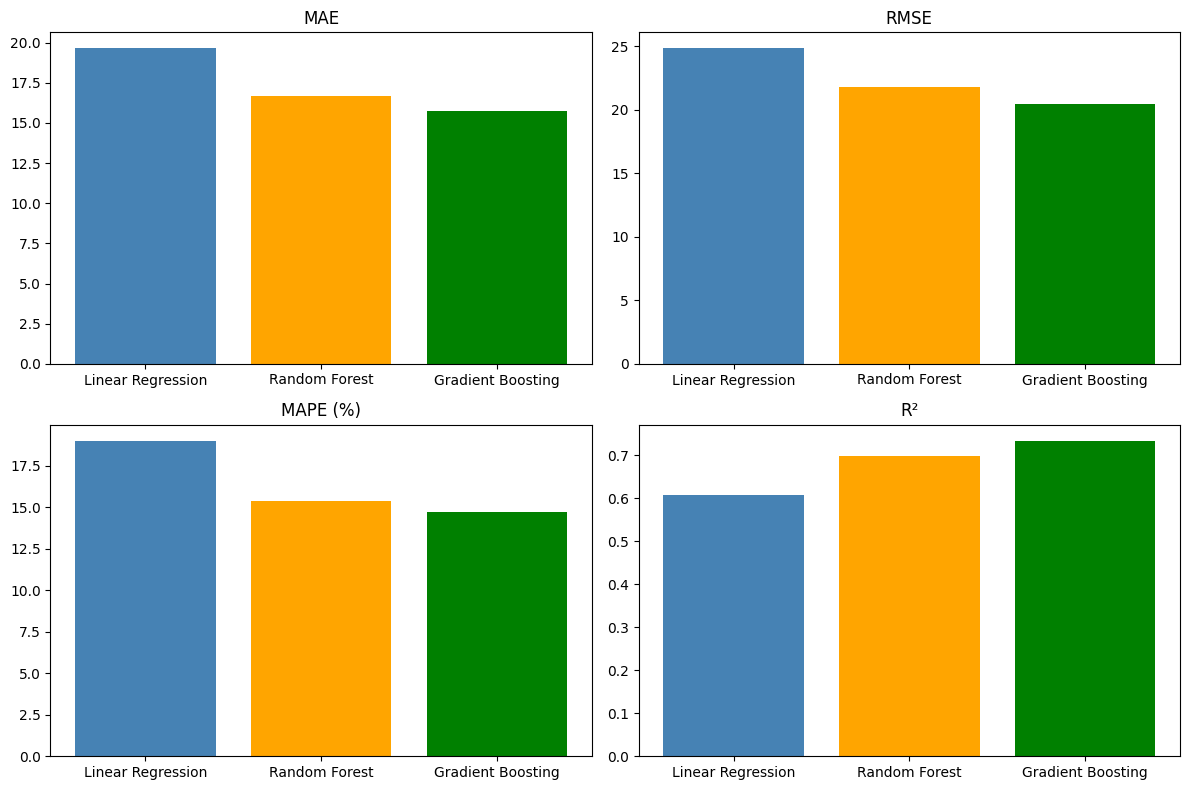

In [39]:
import matplotlib.pyplot as plt

colores = ["steelblue", "orange", "green"]

fig, axes = plt.subplots(2,2, figsize=(12,8))

axes[0,0].bar(resultados["Modelo"], resultados["MAE"], color=colores)
axes[0,0].set_title("MAE")

axes[0,1].bar(resultados["Modelo"], resultados["RMSE"], color=colores)
axes[0,1].set_title("RMSE")

axes[1,0].bar(resultados["Modelo"], resultados["MAPE"], color=colores)
axes[1,0].set_title("MAPE (%)")

axes[1,1].bar(resultados["Modelo"], resultados["R2"], color=colores)
axes[1,1].set_title("R²")

plt.tight_layout()
plt.show()

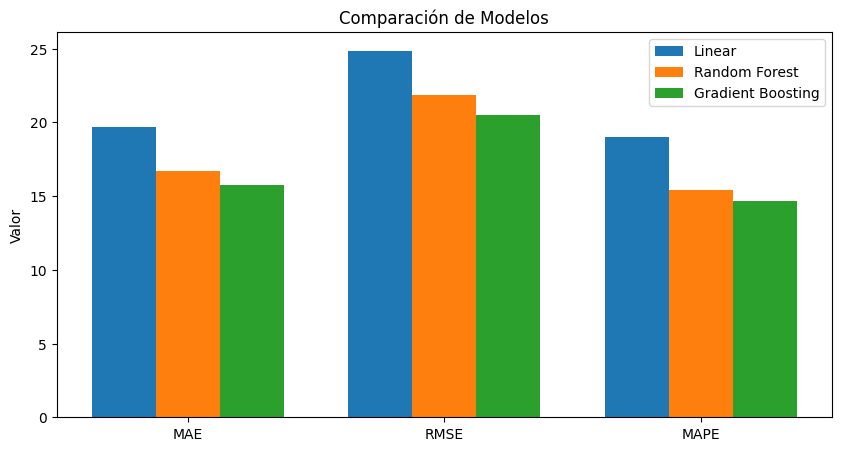

In [41]:
import numpy as np
import matplotlib.pyplot as plt

metricas = ["MAE","RMSE","MAPE"]
gb = [mae_gb, rmse_gb, mape_gb]
rf = [mae_rf, rmse_rf, mape_rf]
lr = [mae_lr, rmse_lr, mape_lr]

x = np.arange(len(metricas))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x-width, lr, width, label="Linear")
plt.bar(x, rf, width, label="Random Forest")
plt.bar(x+width, gb, width, label="Gradient Boosting")

plt.xticks(x, metricas)
plt.ylabel("Valor")
plt.title("Comparación de Modelos")
plt.legend()

plt.show()

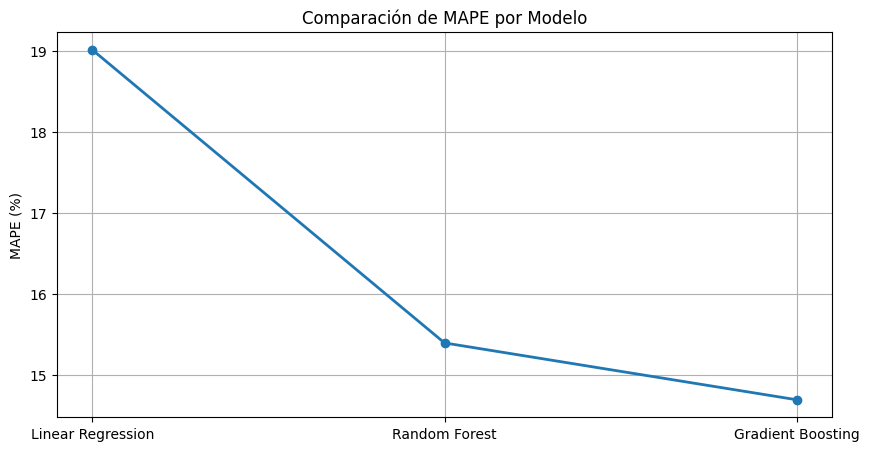

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    resultados["Modelo"],
    resultados["MAPE"],
    marker="o",
    linewidth=2
)

plt.title("Comparación de MAPE por Modelo")
plt.ylabel("MAPE (%)")
plt.grid(True)

plt.show()

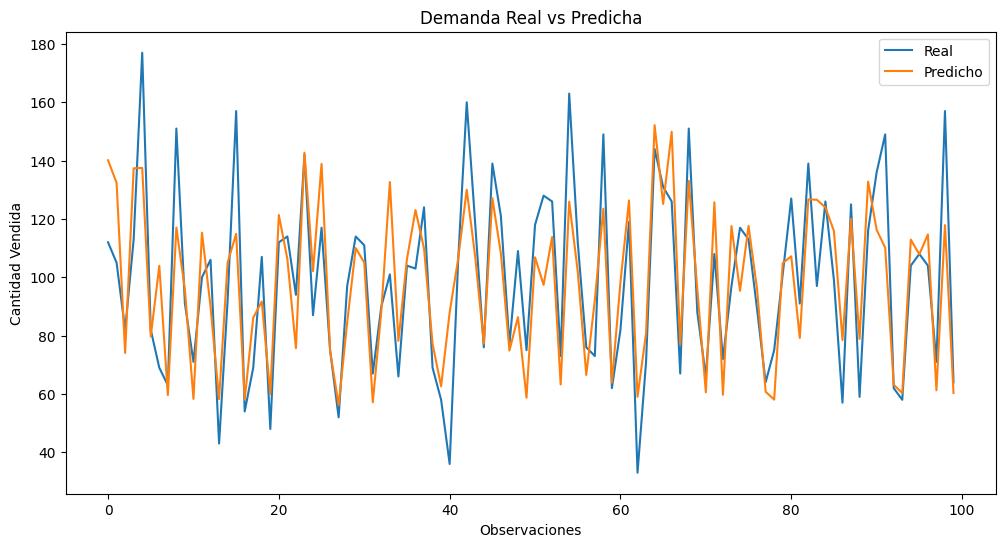

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Real"
)

plt.plot(
    y_pred_gb[:100],
    label="Predicho"
)

plt.title("Demanda Real vs Predicha")
plt.xlabel("Observaciones")
plt.ylabel("Cantidad Vendida")

plt.legend()

plt.show()

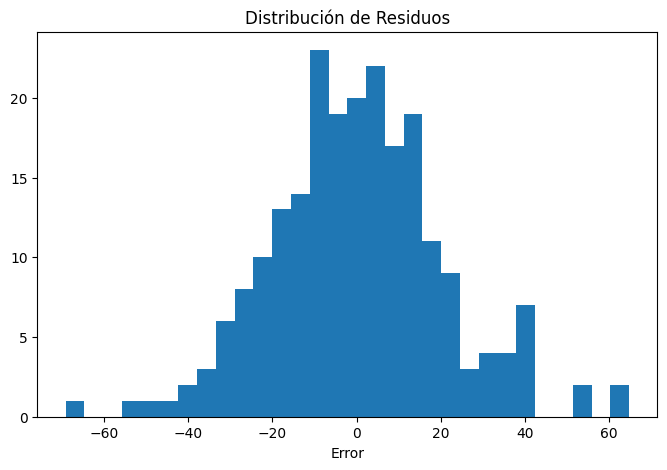

In [37]:
residuos = y_test - y_pred_gb

plt.figure(figsize=(8,5))

plt.hist(residuos, bins=30)

plt.title("Distribución de Residuos")
plt.xlabel("Error")

plt.show()

In [38]:
#optimizacion de hiperparametros
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

grid_gb = GridSearchCV(
    gb_pipeline,
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print(grid_gb.best_params_)

{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300}


In [40]:
best_gb = grid_gb.best_estimator_

y_pred_best = best_gb.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mape_best = mean_absolute_percentage_error(y_test, y_pred_best) * 100
r2_best = r2_score(y_test, y_pred_best)

print(f"MAE  : {mae_best:.2f}")
print(f"RMSE : {rmse_best:.2f}")
print(f"MAPE : {mape_best:.2f}%")
print(f"R²   : {r2_best:.4f}")

MAE  : 15.78
RMSE : 20.68
MAPE : 14.75%
R²   : 0.7288


In [42]:
feature_names = (
    gb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importancias = (
    gb_model.named_steps["model"]
    .feature_importances_
)

fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importancias
})

fi = fi.sort_values(
    "Importance",
    ascending=False
)

fi.head(20)

,Feature,Importance
35,remainder__ventas_roll7,0.886477
22,remainder__temperatura_maxima_celsius,0.012901
34,remainder__ventas_lag7,0.012730
26,remainder__numero_dia_semana,0.012655
29,remainder__es_fin_de_semana,0.011525
21,remainder__temperatura_promedio_celsius,0.008192
17,remainder__inversion_ads_total,0.008113
31,remainder__es_quincena,0.007906
33,remainder__ventas_lag1,0.005435
14,remainder__precio_unitario_promedio,0.004202


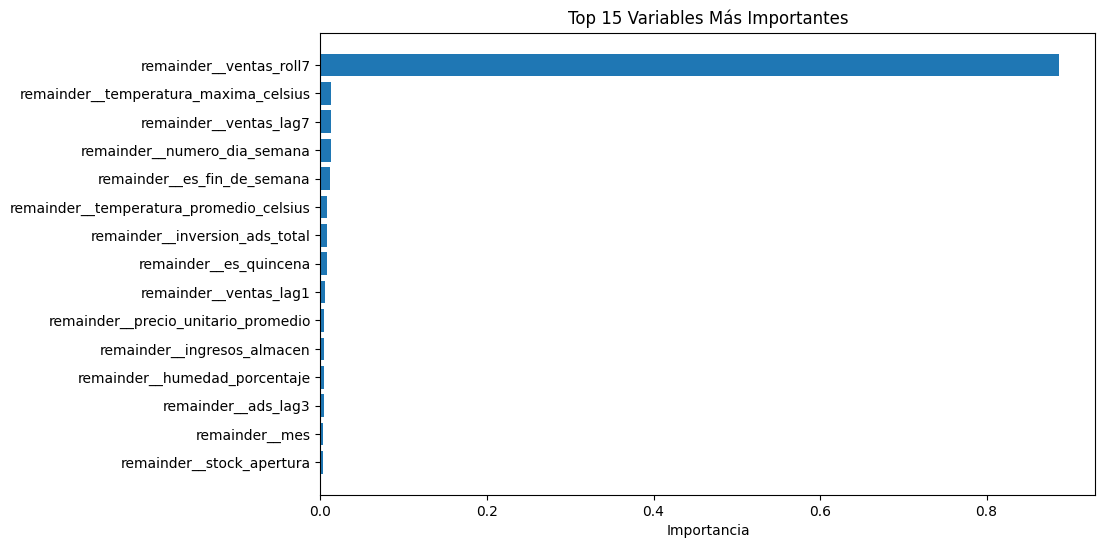

In [43]:
import matplotlib.pyplot as plt

top15 = fi.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.title("Top 15 Variables Más Importantes")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

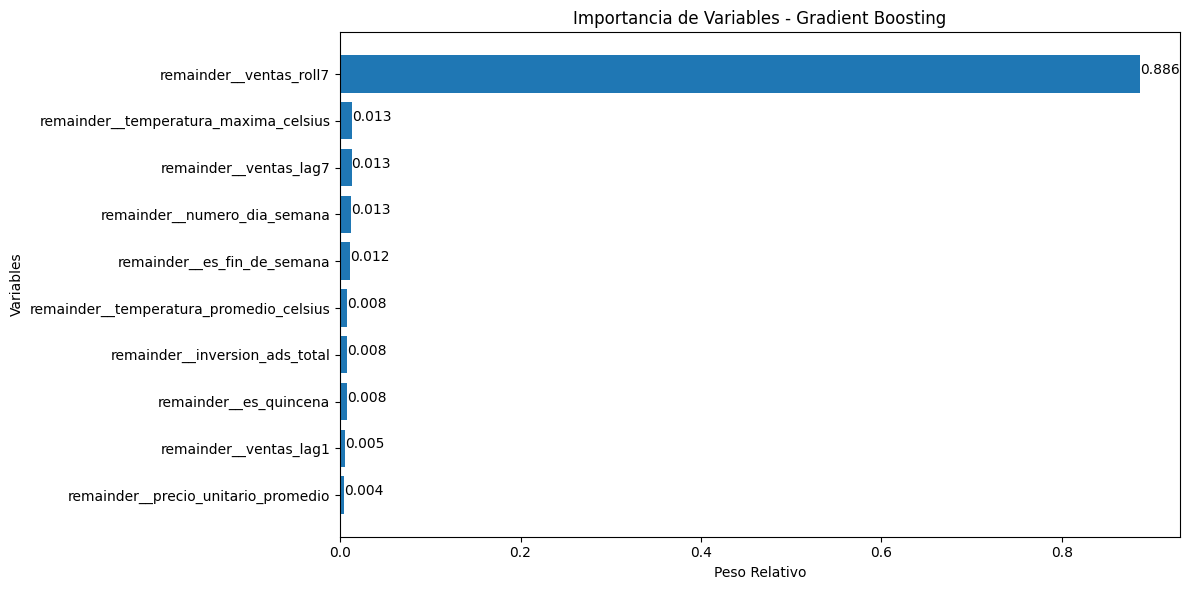

In [45]:
import matplotlib.pyplot as plt

top10 = fi.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Importancia de Variables - Gradient Boosting")
plt.xlabel("Peso Relativo")
plt.ylabel("Variables")

plt.gca().invert_yaxis()

for i, v in enumerate(top10["Importance"]):
    plt.text(v, i, f"{v:.3f}")

plt.tight_layout()
plt.show()

El análisis de importancia de variables mostró que la característica con mayor influencia sobre la predicción fue ventas_roll7, con una importancia relativa de 88.65%. Esto indica que el comportamiento reciente de la demanda es el principal predictor de las ventas futuras. Asimismo, variables climáticas como la temperatura máxima, variables temporales como el día de la semana y el fin de semana, así como variables comerciales como la inversión publicitaria y el precio promedio, también contribuyen a la capacidad predictiva del modelo, aunque en menor medida. Estos resultados son consistentes con la naturaleza de la demanda de agua embotellada, donde los patrones históricos de consumo y las condiciones climáticas influyen significativamente en el comportamiento de compra.

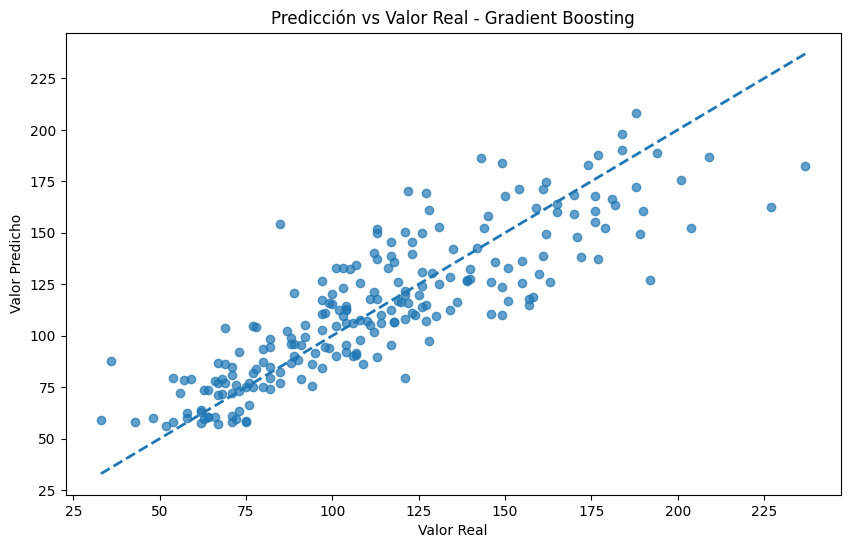

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred_gb, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--',
    linewidth=2
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Predicción vs Valor Real - Gradient Boosting")

plt.show()

Cada punto representa una observación.
La línea diagonal representa la predicción perfecta.
Mientras más cerca estén los puntos de la línea, mejor predice el modelo.
Si los puntos están dispersos, existe mayor error.

In [48]:
#adaptando estructura de tabla gold
from datetime import datetime

ml_feature_importance = fi.copy()

ml_feature_importance["modelo_version"] = "GradientBoosting_v1"

ml_feature_importance["ranking"] = range(
    1,
    len(ml_feature_importance) + 1
)

ml_feature_importance["fecha_entrenamiento"] = datetime.now()

ml_feature_importance["usuario_ejecucion"] = "train_model"

ml_feature_importance["id_importance"] = range(
    1,
    len(ml_feature_importance) + 1
)

ml_feature_importance = ml_feature_importance[
    [
        "id_importance",
        "modelo_version",
        "Feature",
        "Importance",
        "ranking",
        "fecha_entrenamiento",
        "usuario_ejecucion"
    ]
]

ml_feature_importance.head()

,id_importance,modelo_version,Feature,Importance,ranking,fecha_entrenamiento,usuario_ejecucion
35,1,GradientBoosting_v1,remainder__ventas_roll7,0.886477,1,2026-05-31 16:16:10.856671,train_model
22,2,GradientBoosting_v1,remainder__temperatura_maxima_celsius,0.012901,2,2026-05-31 16:16:10.856671,train_model
34,3,GradientBoosting_v1,remainder__ventas_lag7,0.012730,3,2026-05-31 16:16:10.856671,train_model
26,4,GradientBoosting_v1,remainder__numero_dia_semana,0.012655,4,2026-05-31 16:16:10.856671,train_model
29,5,GradientBoosting_v1,remainder__es_fin_de_semana,0.011525,5,2026-05-31 16:16:10.856671,train_model


In [49]:
#renombrando columnas como las que estan definidas en gold
ml_feature_importance = ml_feature_importance.rename(
    columns={
        "Feature": "feature_name",
        "Importance": "importance_value"
    }
)

ml_feature_importance.head()

,id_importance,modelo_version,feature_name,importance_value,ranking,fecha_entrenamiento,usuario_ejecucion
35,1,GradientBoosting_v1,remainder__ventas_roll7,0.886477,1,2026-05-31 16:16:10.856671,train_model
22,2,GradientBoosting_v1,remainder__temperatura_maxima_celsius,0.012901,2,2026-05-31 16:16:10.856671,train_model
34,3,GradientBoosting_v1,remainder__ventas_lag7,0.012730,3,2026-05-31 16:16:10.856671,train_model
26,4,GradientBoosting_v1,remainder__numero_dia_semana,0.012655,4,2026-05-31 16:16:10.856671,train_model
29,5,GradientBoosting_v1,remainder__es_fin_de_semana,0.011525,5,2026-05-31 16:16:10.856671,train_model


In [50]:
#verificando
ml_feature_importance.info()

<class 'pandas.DataFrame'>
Index: 39 entries, 35 to 38
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_importance        39 non-null     int64         
 1   modelo_version       39 non-null     str           
 2   feature_name         39 non-null     str           
 3   importance_value     39 non-null     float64       
 4   ranking              39 non-null     int64         
 5   fecha_entrenamiento  39 non-null     datetime64[us]
 6   usuario_ejecucion    39 non-null     str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 4.6 KB


In [52]:
ml_feature_importance.to_csv(
    "../data/2.-Gold/ml_feature_importance.csv",
    index=False
)